# Lista de Exercícios E5 – Text Mining
## RAD2010 – Análise de Dados para Gestão de Negócios

Análise de mineração de textos sobre Business Analytics

## Instalação e Importação de Bibliotecas

In [1]:
# Download do modelo de português do spaCy
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 41.8 MB/s  0:00:0040.1 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


In [9]:
# Importação das bibliotecas
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from rake_nltk import Rake
import networkx as nx
from itertools import combinations
import nltk
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Download de recursos do NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("Bibliotecas importadas com sucesso!")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gbpleone/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/gbpleone/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/gbpleone/nltk_data...


Bibliotecas importadas com sucesso!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
# Carregamento do modelo spaCy para português
nlp = spacy.load('pt_core_news_sm')
print("Modelo spaCy carregado com sucesso!")

Modelo spaCy carregado com sucesso!


## Carregamento do Texto

In [4]:
# Leitura do arquivo de texto
with open('L05texto.txt', 'r', encoding='utf-8') as file:
    texto = file.read()

print("Texto carregado com sucesso!")
print(f"Tamanho do texto: {len(texto)} caracteres")

Texto carregado com sucesso!
Tamanho do texto: 10843 caracteres


---
# Questão 1
## Análise de Mineração de Textos

### 1a) Número de documentos e quantidade de tokens por documento

In [5]:
# Dividir o texto em documentos (parágrafos não vazios)
documentos = [p.strip() for p in texto.split('\n\n') if p.strip()]
num_documentos = len(documentos)

print(f"Número de documentos: {num_documentos}")
print("\n" + "="*80)
print("Quantidade de tokens por documento:")
print("="*80)

# Processar cada documento e contar tokens
tokens_por_documento = []
for i, doc in enumerate(documentos, 1):
    doc_processado = nlp(doc)
    num_tokens = len([token for token in doc_processado if not token.is_space])
    tokens_por_documento.append(num_tokens)
    print(f"Documento {i}: {num_tokens} tokens")

print("\n" + "="*80)
print(f"Total de tokens: {sum(tokens_por_documento)}")
print(f"Média de tokens por documento: {np.mean(tokens_por_documento):.2f}")

Número de documentos: 9

Quantidade de tokens por documento:
Documento 1: 94 tokens
Documento 2: 82 tokens
Documento 3: 144 tokens
Documento 4: 344 tokens
Documento 5: 301 tokens
Documento 6: 200 tokens
Documento 7: 301 tokens
Documento 8: 150 tokens
Documento 9: 117 tokens

Total de tokens: 1733
Média de tokens por documento: 192.56


### 1b) Gráfico de frequência dos substantivos que mais ocorrem

Top 20 substantivos mais frequentes:
      Substantivo  Frequência
0            dado          37
1         empresa          23
2         decisão          10
3         análise          10
4         mercado           8
5        processo           7
6       tendência           7
7         cliente           7
8      ferramenta           7
9         desafio           7
10      benefício           6
11  comportamento           6
12        negócio           5
13          setor           5
14          venda           5
15     disciplina           4
16     tecnologia           4
17            uso           4
18        maneira           4
19      qualidade           4


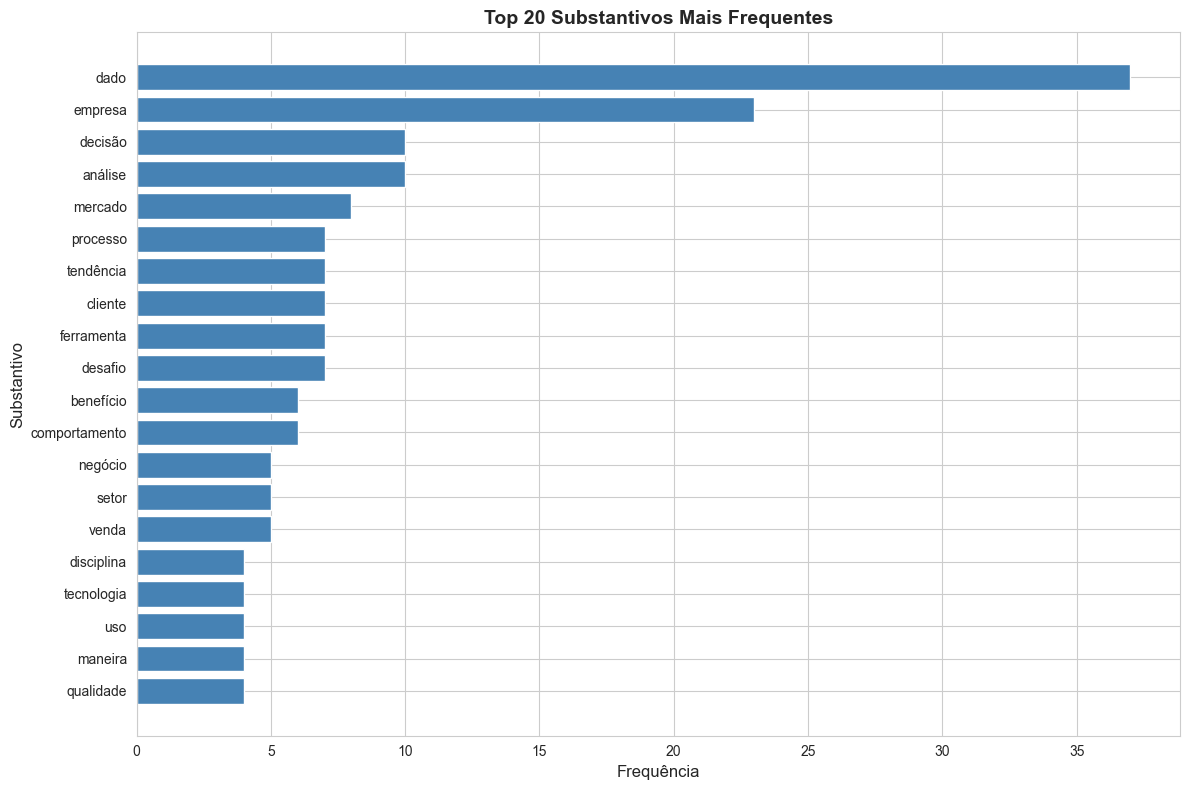

In [6]:
# Processar todo o texto
doc_completo = nlp(texto)

# Extrair substantivos (NOUN)
substantivos = [token.lemma_.lower() for token in doc_completo 
                if token.pos_ == 'NOUN' and not token.is_stop and len(token.text) > 2]

# Contar frequências
freq_substantivos = Counter(substantivos)
top_substantivos = freq_substantivos.most_common(20)

# Criar DataFrame
df_substantivos = pd.DataFrame(top_substantivos, columns=['Substantivo', 'Frequência'])

print("Top 20 substantivos mais frequentes:")
print(df_substantivos)

# Plotar gráfico
plt.figure(figsize=(12, 8))
plt.barh(df_substantivos['Substantivo'], df_substantivos['Frequência'], color='steelblue')
plt.xlabel('Frequência', fontsize=12)
plt.ylabel('Substantivo', fontsize=12)
plt.title('Top 20 Substantivos Mais Frequentes', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 1c) Gráfico de frequência dos adjetivos que mais ocorrem

Top 20 adjetivos mais frequentes:
       Adjetivo  Frequência
0      insights           5
1   operacional           5
2   estatístico           4
3     principal           4
4   empresarial           4
5        futuro           4
6    financeiro           4
7     histórico           3
8      anterior           3
9        eficaz           3
10   disponível           3
11    essencial           3
12  corporativo           2
13      moderno           2
14        atual           2
15  competitivo           2
16   específico           2
17   importante           2
18    analítico           2
19       social           2


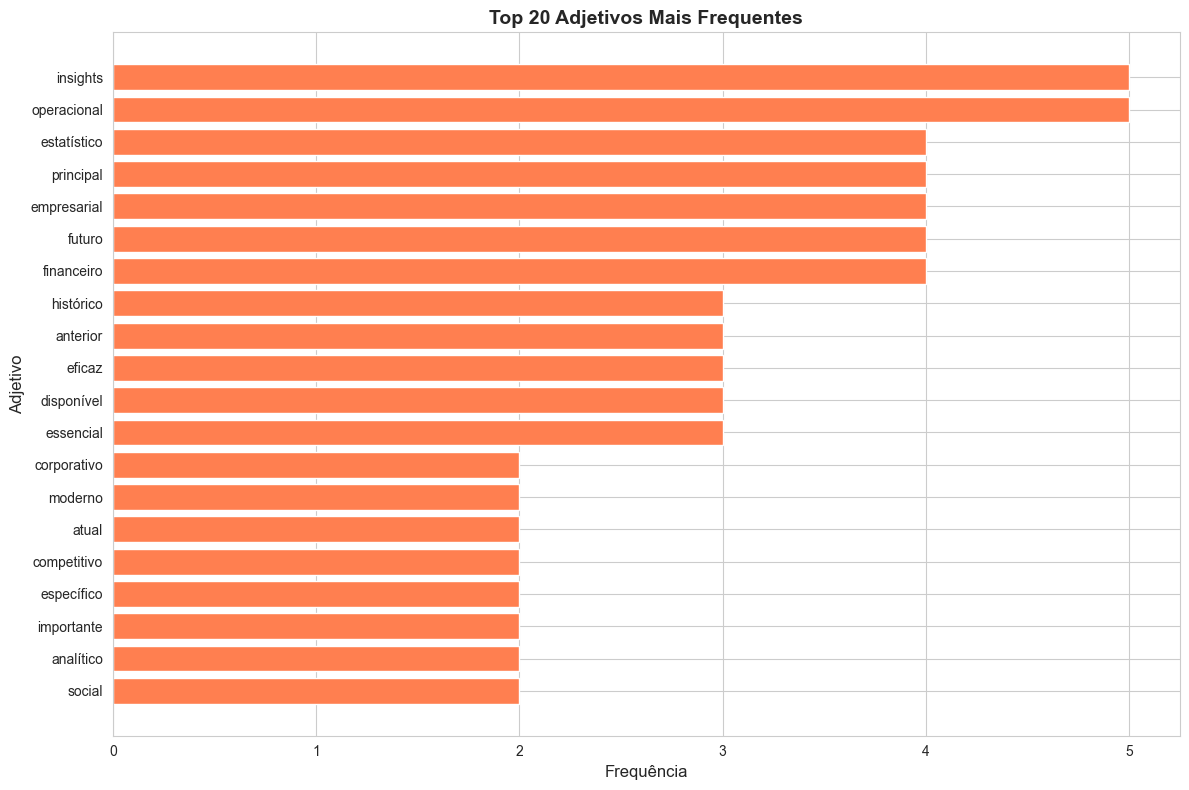

In [7]:
# Extrair adjetivos (ADJ)
adjetivos = [token.lemma_.lower() for token in doc_completo 
             if token.pos_ == 'ADJ' and not token.is_stop and len(token.text) > 2]

# Contar frequências
freq_adjetivos = Counter(adjetivos)
top_adjetivos = freq_adjetivos.most_common(20)

# Criar DataFrame
df_adjetivos = pd.DataFrame(top_adjetivos, columns=['Adjetivo', 'Frequência'])

print("Top 20 adjetivos mais frequentes:")
print(df_adjetivos)

# Plotar gráfico
plt.figure(figsize=(12, 8))
plt.barh(df_adjetivos['Adjetivo'], df_adjetivos['Frequência'], color='coral')
plt.xlabel('Frequência', fontsize=12)
plt.ylabel('Adjetivo', fontsize=12)
plt.title('Top 20 Adjetivos Mais Frequentes', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 1d) Método RAKE - Palavras-chave mais frequentes

Top 20 palavras-chave extraídas pelo método RAKE:
        Score                                      Palavra-chave
0   33.205263  utilizar business analytics requer competência...
1   27.038596  business analytics pode exigir investimentos s...
2   20.119048    principais benefícios dessa abordagem analítica
3   19.399314           dados empresas modernas geralmente lidam
4   18.324311       business analytics ofereça muitos benefícios
5   17.077193       business analytics business analytics refere
6   16.338596      business analytics existem várias ferramentas
7   15.077193         business analytics business analytics pode
8   14.881832           empresas podem prever tendências futuras
9   14.038596                business analytics parece promissor
10  13.583333                      máximo valor dessa disciplina
11  13.578261                   empresas podem precisar investir
12  13.350000                        baixa qualidade podem levar
13  12.708333                 algumas te

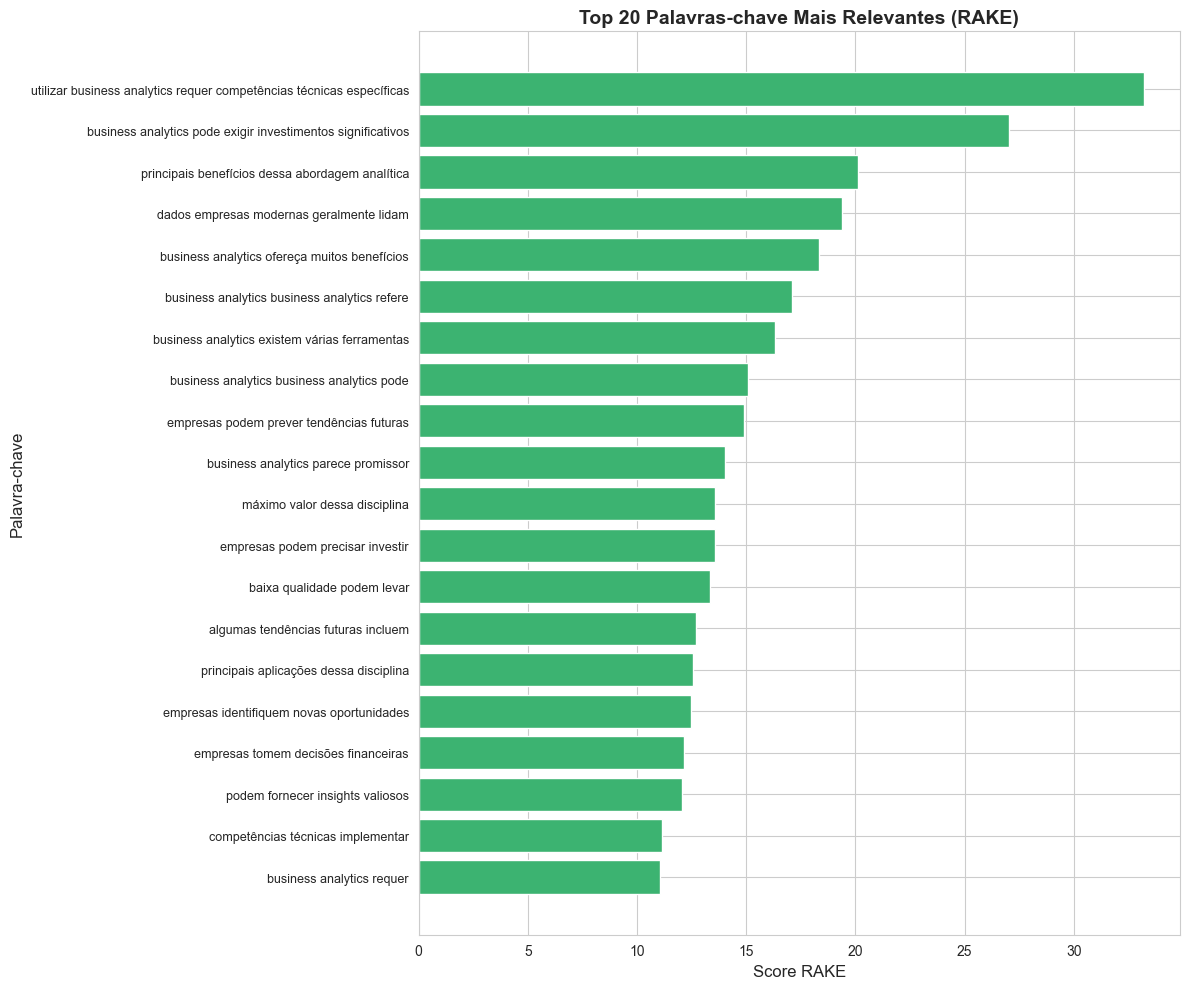

In [10]:
# Configurar RAKE para português
rake = Rake(language='portuguese')

# Extrair palavras-chave
rake.extract_keywords_from_text(texto)
keywords_scores = rake.get_ranked_phrases_with_scores()

# Pegar as top 20 palavras-chave
top_keywords = keywords_scores[:20]

# Criar DataFrame
df_keywords = pd.DataFrame(top_keywords, columns=['Score', 'Palavra-chave'])

print("Top 20 palavras-chave extraídas pelo método RAKE:")
print(df_keywords)

# Plotar gráfico
plt.figure(figsize=(12, 10))
plt.barh(range(len(df_keywords)), df_keywords['Score'], color='mediumseagreen')
plt.yticks(range(len(df_keywords)), df_keywords['Palavra-chave'], fontsize=9)
plt.xlabel('Score RAKE', fontsize=12)
plt.ylabel('Palavra-chave', fontsize=12)
plt.title('Top 20 Palavras-chave Mais Relevantes (RAKE)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 1e) Rede de Coocorrências (ADJ, NOUN, PROPN, VERB)

In [11]:
# Dividir o texto em sentenças
sentencas = [sent for sent in doc_completo.sents]

# Definir os UPOS de interesse
upos_interesse = ['ADJ', 'NOUN', 'PROPN', 'VERB']

# Coletar coocorrências
coocorrencias = []

for sent in sentencas:
    # Filtrar tokens relevantes
    tokens_relevantes = [token.lemma_.lower() for token in sent 
                         if token.pos_ in upos_interesse and not token.is_stop and len(token.text) > 2]
    
    # Gerar pares de coocorrências
    if len(tokens_relevantes) >= 2:
        pares = list(combinations(tokens_relevantes, 2))
        coocorrencias.extend(pares)

# Contar coocorrências
freq_coocorrencias = Counter(coocorrencias)
top_coocorrencias = freq_coocorrencias.most_common(100)

print(f"Total de coocorrências únicas: {len(freq_coocorrencias)}")
print(f"\nTop 10 coocorrências mais frequentes:")
for (palavra1, palavra2), freq in top_coocorrencias[:10]:
    print(f"{palavra1} <-> {palavra2}: {freq}")

Total de coocorrências únicas: 3952

Top 10 coocorrências mais frequentes:
business <-> analytics: 42
analytics <-> dado: 16
business <-> dado: 14
analytics <-> empresa: 10
business <-> empresa: 9
empresa <-> dado: 8
analisar <-> dado: 8
business <-> análise: 7
analytics <-> análise: 7
business <-> decisão: 6


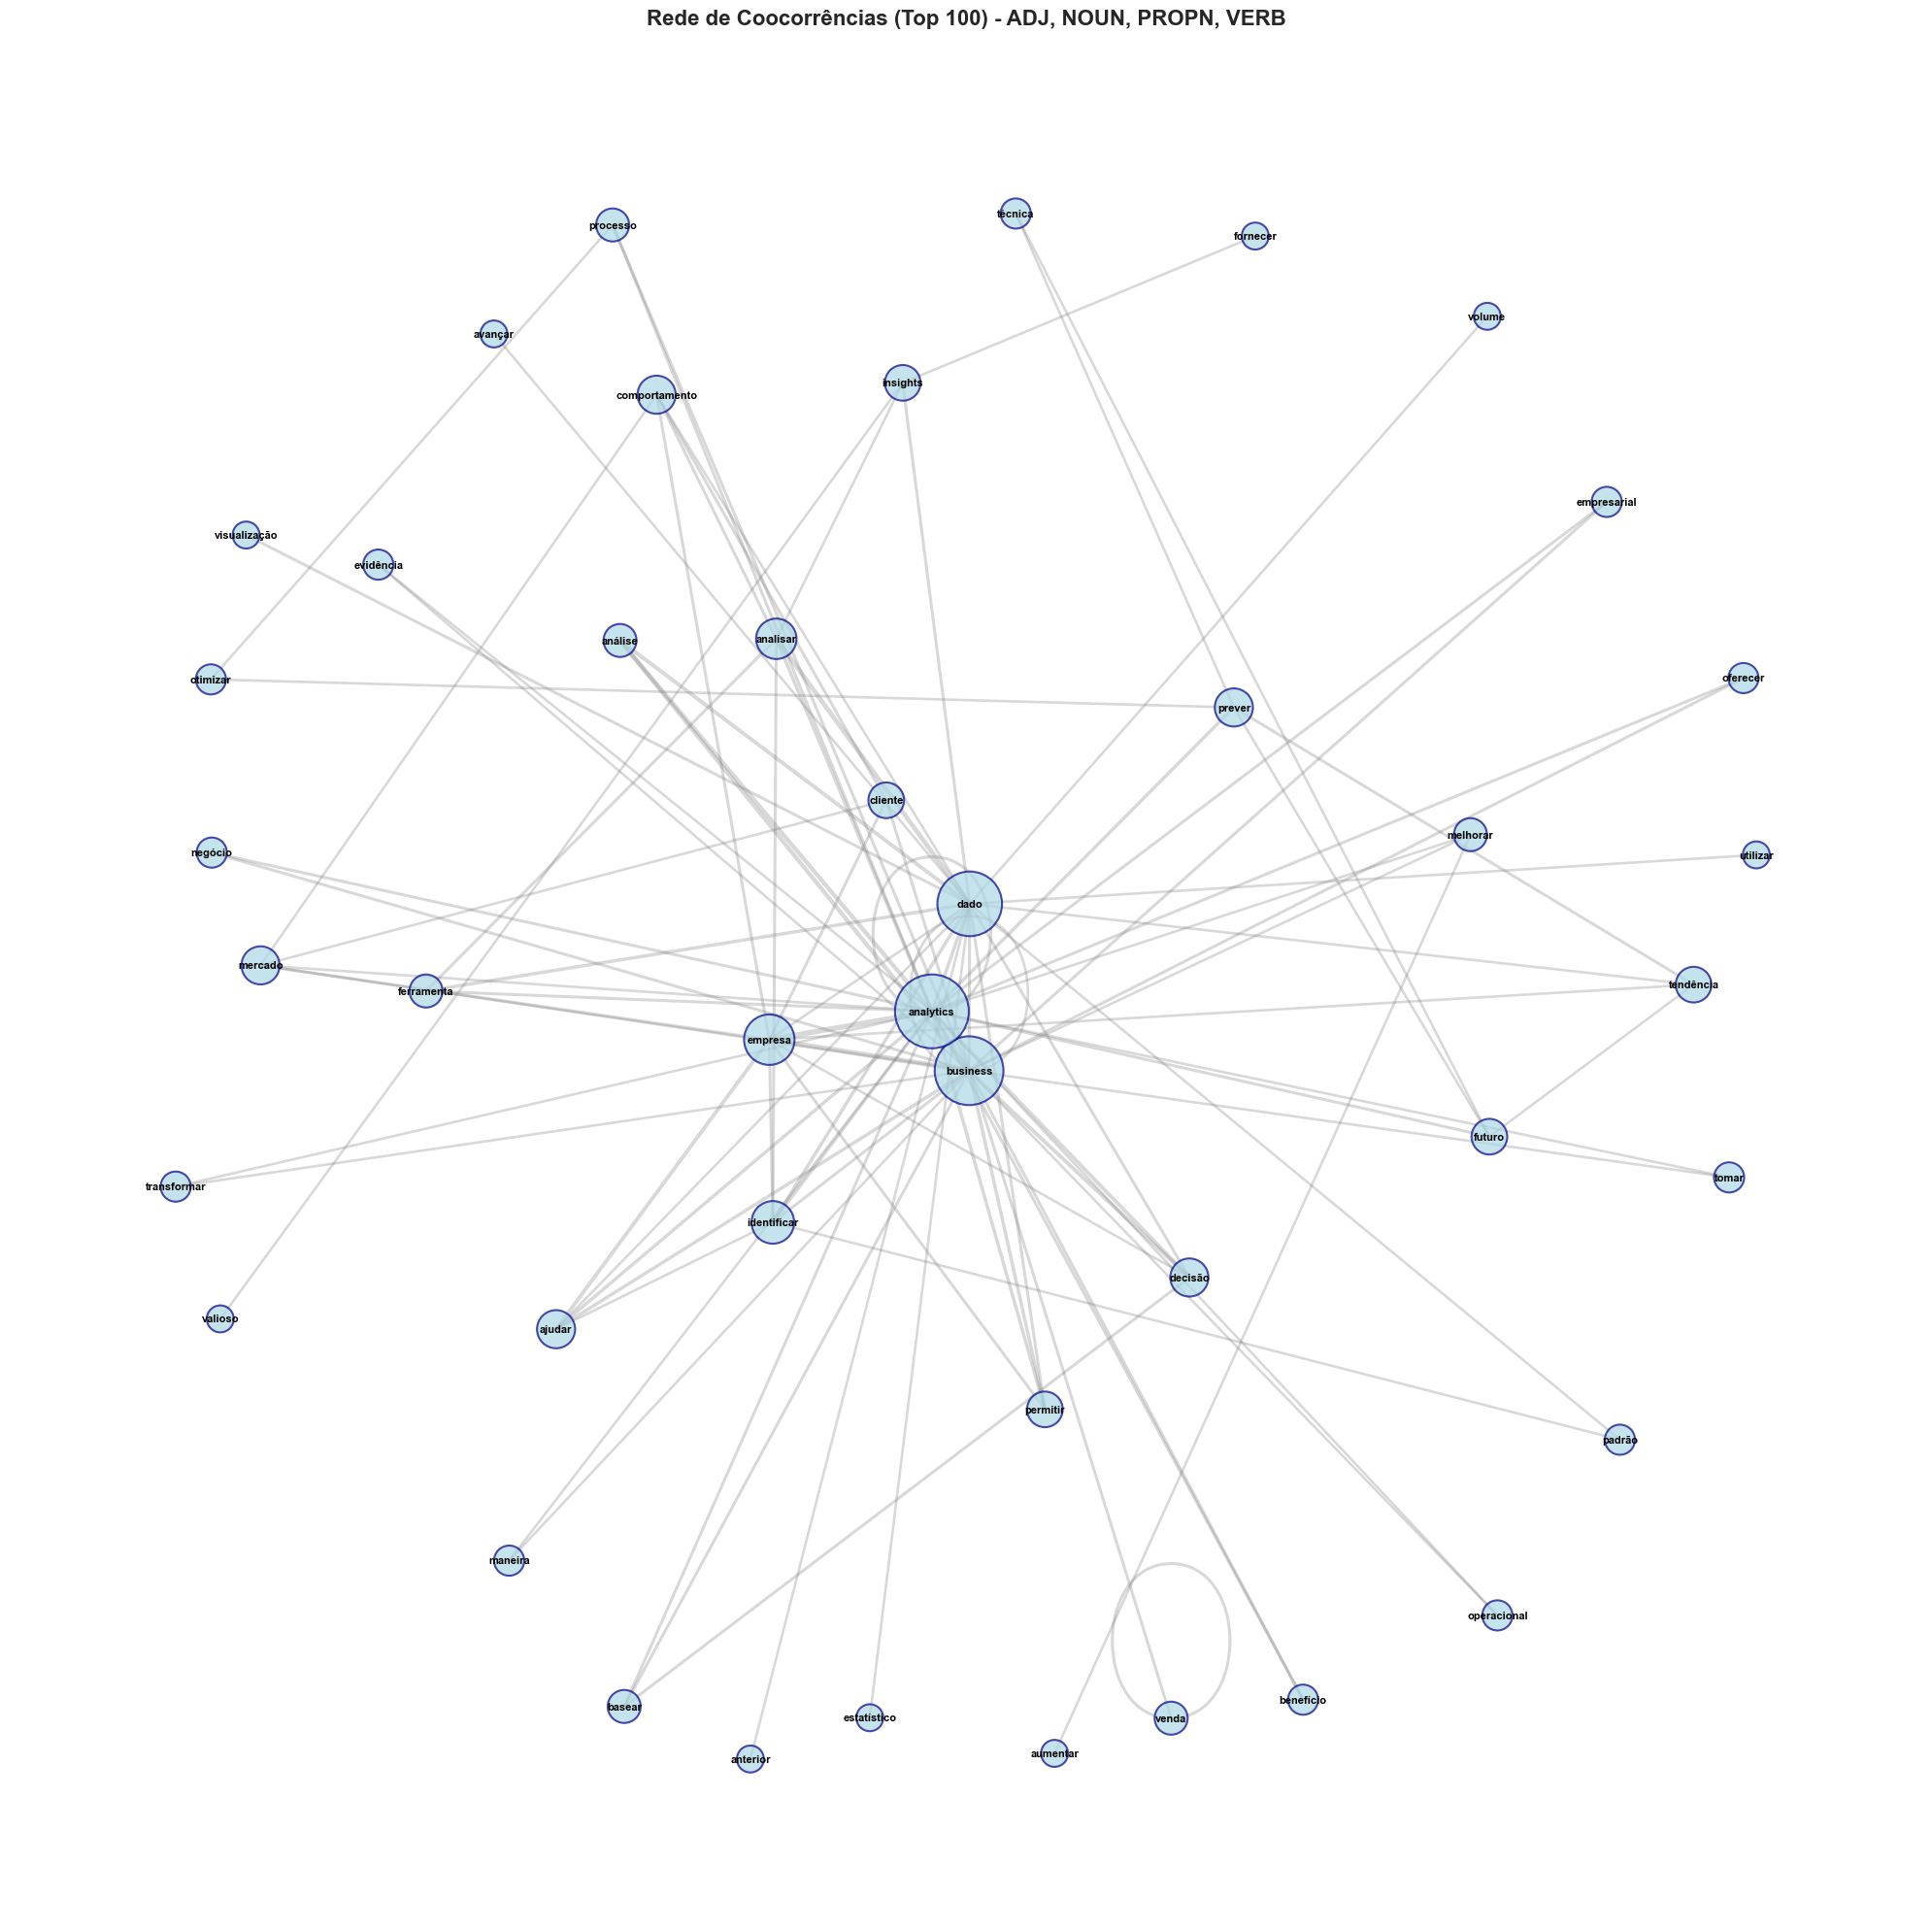


Estatísticas da rede:
Número de nós (palavras): 43
Número de arestas (coocorrências): 95
Densidade da rede: 0.1052


In [12]:
# Criar grafo de coocorrências
G = nx.Graph()

for (palavra1, palavra2), freq in top_coocorrencias:
    G.add_edge(palavra1, palavra2, weight=freq)

# Configurar layout e visualização
plt.figure(figsize=(20, 20))
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Calcular tamanhos dos nós baseado no grau
node_sizes = [300 + 100 * G.degree(node) for node in G.nodes()]

# Calcular larguras das arestas baseado no peso
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
max_weight = max(weights)
edge_widths = [1 + 3 * (w / max_weight) for w in weights]

# Desenhar o grafo
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', 
                       alpha=0.7, edgecolors='darkblue', linewidths=1.5)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title('Rede de Coocorrências (Top 100) - ADJ, NOUN, PROPN, VERB', 
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nEstatísticas da rede:")
print(f"Número de nós (palavras): {G.number_of_nodes()}")
print(f"Número de arestas (coocorrências): {G.number_of_edges()}")
print(f"Densidade da rede: {nx.density(G):.4f}")

---
# Questão 2
## Modelagem de Tópicos - LDA (Latent Dirichlet Allocation)

### Preparação dos dados para LDA

In [13]:
# Processar documentos para LDA
documentos_processados = []

for doc_texto in documentos:
    doc_nlp = nlp(doc_texto)
    # Extrair tokens relevantes (substantivos, verbos, adjetivos)
    tokens = [token.lemma_.lower() for token in doc_nlp 
              if token.pos_ in ['NOUN', 'VERB', 'ADJ', 'PROPN'] 
              and not token.is_stop 
              and len(token.text) > 2
              and token.is_alpha]
    documentos_processados.append(tokens)

print(f"Número de documentos processados: {len(documentos_processados)}")
print(f"\nExemplo do primeiro documento (primeiras 20 palavras):")
print(documentos_processados[0][:20])

Número de documentos processados: 9

Exemplo do primeiro documento (primeiras 20 palavras):
['mundo', 'corporativo', 'moderno', 'empresa', 'bombardear', 'volume', 'dado', 'dado', 'analisar', 'interpretar', 'fornecer', 'insights', 'valioso', 'ajudar', 'tomada', 'decisão', 'estratégico', 'contexto', 'surgir', 'conceito']


In [14]:
# Criar dicionário e corpus
dictionary = corpora.Dictionary(documentos_processados)

# Filtrar termos muito frequentes ou muito raros
dictionary.filter_extremes(no_below=1, no_above=0.8)

# Criar corpus (bag of words)
corpus = [dictionary.doc2bow(doc) for doc in documentos_processados]

print(f"Tamanho do dicionário: {len(dictionary)}")
print(f"Número de documentos no corpus: {len(corpus)}")

Tamanho do dicionário: 372
Número de documentos no corpus: 9


### 2a) Modelo LDA com 3 tópicos - Matriz de documentos por tópicos

In [15]:
# Treinar modelo LDA com 3 tópicos
num_topics = 3
lda_model = LdaModel(corpus=corpus,
                     id2word=dictionary,
                     num_topics=num_topics,
                     random_state=42,
                     passes=10,
                     alpha='auto',
                     per_word_topics=True)

print("Modelo LDA treinado com sucesso!\n")

# Exibir os 3 tópicos com suas palavras mais relevantes
print("Tópicos identificados:")
print("="*80)
for idx, topic in lda_model.print_topics(num_topics=num_topics, num_words=10):
    print(f"\nTópico {idx + 1}:")
    print(topic)

Modelo LDA treinado com sucesso!

Tópicos identificados:

Tópico 1:
0.019*"analisar" + 0.019*"análise" + 0.014*"ferramenta" + 0.012*"permitir" + 0.012*"comportamento" + 0.012*"venda" + 0.010*"prever" + 0.010*"ajudar" + 0.010*"futuro" + 0.010*"tendência"

Tópico 2:
0.026*"desafio" + 0.014*"decisão" + 0.014*"implementação" + 0.014*"cultura" + 0.010*"custo" + 0.010*"qualidade" + 0.010*"basear" + 0.010*"utilizar" + 0.010*"precisar" + 0.010*"essencial"

Tópico 3:
0.016*"identificar" + 0.013*"processo" + 0.013*"mercado" + 0.013*"cliente" + 0.013*"decisão" + 0.011*"futuro" + 0.011*"prever" + 0.011*"otimizar" + 0.011*"ajudar" + 0.011*"melhorar"


In [16]:
# Obter a matriz de documentos por tópicos
doc_topic_dist = []

for doc_bow in corpus:
    topic_dist = lda_model.get_document_topics(doc_bow, minimum_probability=0)
    # Ordenar por índice do tópico e extrair apenas as probabilidades
    topic_dist = sorted(topic_dist, key=lambda x: x[0])
    probs = [prob for _, prob in topic_dist]
    doc_topic_dist.append(probs)

# Criar DataFrame
doc_topic_df = pd.DataFrame(doc_topic_dist, 
                            columns=[f'Tópico {i+1}' for i in range(num_topics)])
doc_topic_df.index = [f'Documento {i+1}' for i in range(len(documentos))]

print("\nMatriz de Documentos por Tópicos:")
print("="*80)
print(doc_topic_df)

# Adicionar coluna com o tópico dominante
doc_topic_df['Tópico Dominante'] = doc_topic_df.iloc[:, :num_topics].idxmax(axis=1)

print("\n" + "="*80)
print("Distribuição com tópico dominante:")
print(doc_topic_df)


Matriz de Documentos por Tópicos:
             Tópico 1  Tópico 2  Tópico 3
Documento 1  0.997512  0.000834  0.001654
Documento 2  0.001543  0.000770  0.997687
Documento 3  0.000988  0.000493  0.998519
Documento 4  0.000450  0.000225  0.999325
Documento 5  0.999319  0.000228  0.000453
Documento 6  0.998931  0.000358  0.000711
Documento 7  0.000511  0.998983  0.000506
Documento 8  0.998505  0.000501  0.000994
Documento 9  0.001281  0.000639  0.998080

Distribuição com tópico dominante:
             Tópico 1  Tópico 2  Tópico 3 Tópico Dominante
Documento 1  0.997512  0.000834  0.001654         Tópico 1
Documento 2  0.001543  0.000770  0.997687         Tópico 3
Documento 3  0.000988  0.000493  0.998519         Tópico 3
Documento 4  0.000450  0.000225  0.999325         Tópico 3
Documento 5  0.999319  0.000228  0.000453         Tópico 1
Documento 6  0.998931  0.000358  0.000711         Tópico 1
Documento 7  0.000511  0.998983  0.000506         Tópico 2
Documento 8  0.998505  0.000501  0.00

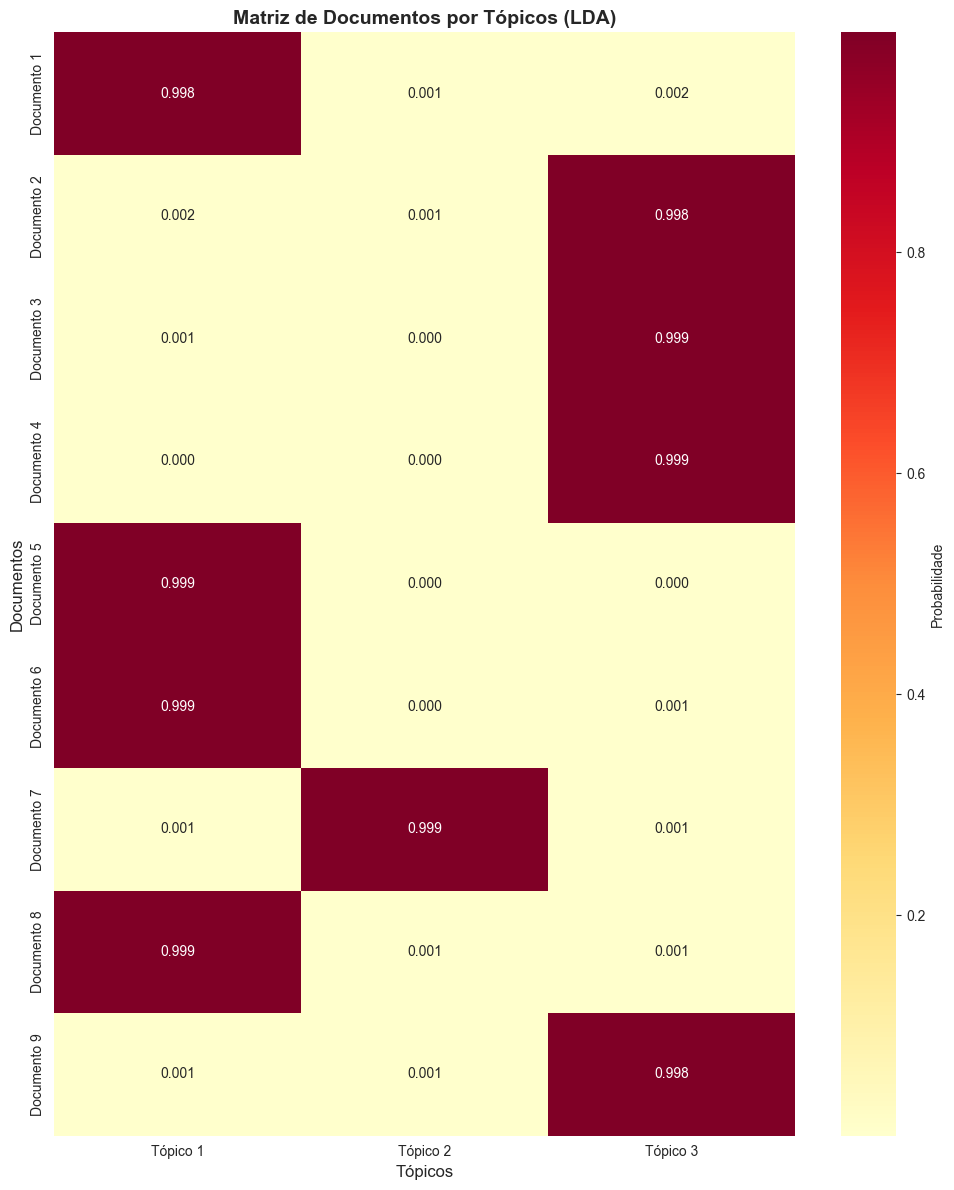

In [17]:
# Visualizar a matriz como heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(doc_topic_df.iloc[:, :num_topics], annot=True, fmt='.3f', 
            cmap='YlOrRd', cbar_kws={'label': 'Probabilidade'})
plt.title('Matriz de Documentos por Tópicos (LDA)', fontsize=14, fontweight='bold')
plt.xlabel('Tópicos', fontsize=12)
plt.ylabel('Documentos', fontsize=12)
plt.tight_layout()
plt.show()

### 2b) Visualização LDAvis com Tópico 1 selecionado

In [18]:
# Preparar visualização LDAvis
pyLDAvis.enable_notebook()

# Criar visualização
vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)

# Salvar como HTML
pyLDAvis.save_html(vis, 'lda_visualization.html')

print("Visualização LDAvis criada com sucesso!")
print("Arquivo salvo como: lda_visualization.html")
print("\nObservação: A visualização interativa mostrará o Tópico 1 selecionado por padrão.")

# Exibir a visualização
vis

Visualização LDAvis criada com sucesso!
Arquivo salvo como: lda_visualization.html

Observação: A visualização interativa mostrará o Tópico 1 selecionado por padrão.


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.078126 -0.055439       1        1  43.873746
1     -0.094203 -0.031192       2        1  16.613286
2      0.016078  0.086631       3        1  39.512968, topic_info=              Term      Freq     Total Category  logprob  loglift
292        desafio  4.000000  4.000000  Default  30.0000  30.0000
290        cultura  2.000000  2.000000  Default  29.0000  29.0000
135  implementação  2.000000  2.000000  Default  28.0000  28.0000
161      qualidade  2.000000  2.000000  Default  27.0000  27.0000
39          basear  2.000000  2.000000  Default  26.0000  26.0000
..             ...       ...       ...      ...      ...      ...
35         análise  1.645385  8.239957   Topic3  -5.1402  -0.6825
58          padrão  1.625367  2.744839   Topic3  -5.1524   0.4046
30      tecnologia  1.627132  3.225867   Topic3  -5.1513   0.2442
79   comportamento  1.626481  5.606449   Topic3  -5.1517  -0.3090
16     estatístico  1.626076  3.459963   Topic3  -5.1520   0.1735

[185 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
0         1  0.969052  acionável
67        3  0.985856  acontecer
278       2  0.897393     adoção
1         1  0.477396     ajudar
1         3  0.477396     ajudar
...     ...       ...        ...
105       2  0.268336   utilizar
105       3  0.268336   utilizar
337       2  0.897351  valorizar
236       1  0.949610      venda
237       1  0.741724     vendas

[198 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3])